In [ ]:
"""
Normal Distribution Analysis 
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import seaborn as sns

# ── 1. DATASET ────────────────────────────────────────────────────────────────

np.random.seed(42) 

students = {
    "Alice": 82, "Bob": 74, "Carol": 91, "David": 68, "Eva": 85,
    "Frank": 77, "Grace": 95, "Hank": 61, "Iris": 88, "Jack": 72,
    "Karen": 79, "Leo": 65, "Mia": 93, "Nate": 70, "Olivia": 87,
    "Paul": 75, "Quinn": 83, "Rose": 69, "Sam": 90, "Tina": 78,
    "Uma": 84, "Victor": 66, "Wendy": 92, "Xander": 73, "Yara": 81,
    "Zoe": 76, "Aaron": 86, "Beth": 63, "Carl": 89, "Diana": 71,
    "Ethan": 80, "Fiona": 94, "George": 67, "Hannah": 88, "Ivan": 74,
    "Julia": 82, "Kevin": 78, "Laura": 96, "Mike": 64, "Nina": 85,
}

scores = np.array(list(students.values()))
names  = list(students.keys())

In [2]:
# ── 2. DESCRIPTIVE STATISTICS ─────────────────────────────────────────────────

mu      = np.mean(scores)
sigma   = np.std(scores, ddof=1)        # sample std dev
median  = np.median(scores)
mode_r  = stats.mode(scores, keepdims=True)
n       = len(scores)

print("=" * 55)
print("  STUDENT EXAM SCORES — NORMAL DISTRIBUTION ANALYSIS")
print("=" * 55)
print(f"\n  Dataset size : {n} students")
print(f"  Mean   (μ)   : {mu:.2f}")
print(f"  Median       : {median:.2f}")
print(f"  Std Dev (σ)  : {sigma:.2f}")
print(f"  Variance (σ²): {sigma**2:.2f}")
print(f"  Min / Max    : {scores.min()} / {scores.max()}")
print(f"  Skewness     : {stats.skew(scores):.4f}")
print(f"  Kurtosis     : {stats.kurtosis(scores):.4f}")


  STUDENT EXAM SCORES — NORMAL DISTRIBUTION ANALYSIS

  Dataset size : 40 students
  Mean   (μ)   : 79.28
  Median       : 79.50
  Std Dev (σ)  : 9.81
  Variance (σ²): 96.26
  Min / Max    : 61 / 96
  Skewness     : -0.0872
  Kurtosis     : -1.0513


In [3]:
# ── 3. Z-SCORES ───────────────────────────────────────────────────────────────

z_scores = (scores - mu) / sigma

print("\n" + "-" * 55)
print("  Z-SCORES  (top 5 & bottom 5 students)")
print("-" * 55)

ranked = sorted(zip(names, scores, z_scores), key=lambda x: x[2], reverse=True)
print(f"\n  {'Student':<10} {'Score':>6}  {'Z-Score':>8}  {'Percentile':>10}")
print(f"  {'-'*10} {'-'*6}  {'-'*8}  {'-'*10}")
for name, sc, z in ranked[:5] + ranked[-5:]:
    pct = stats.norm.cdf(z) * 100
    print(f"  {name:<10} {sc:>6}  {z:>+8.2f}  {pct:>9.1f}%")


-------------------------------------------------------
  Z-SCORES  (top 5 & bottom 5 students)
-------------------------------------------------------

  Student     Score   Z-Score  Percentile
  ---------- ------  --------  ----------
  Laura          96     +1.70       95.6%
  Grace          95     +1.60       94.6%
  Fiona          94     +1.50       93.3%
  Mia            93     +1.40       91.9%
  Wendy          92     +1.30       90.3%
  Victor         66     -1.35        8.8%
  Leo            65     -1.45        7.3%
  Mike           64     -1.56        6.0%
  Beth           63     -1.66        4.9%
  Hank           61     -1.86        3.1%


In [4]:
# ── 4. EMPIRICAL RULE ─────────────────────────────────────────────────────────

within_1s = np.sum(np.abs(z_scores) <= 1) / n * 100
within_2s = np.sum(np.abs(z_scores) <= 2) / n * 100
within_3s = np.sum(np.abs(z_scores) <= 3) / n * 100

print("\n" + "-" * 55)
print("  EMPIRICAL RULE CHECK")
print("-" * 55)
print(f"\n  ±1σ  ({mu-sigma:.1f} – {mu+sigma:.1f}) : "
      f"{within_1s:.1f}%  students  (expected 68.27%)")
print(f"  ±2σ  ({mu-2*sigma:.1f} – {mu+2*sigma:.1f}) : "
      f"{within_2s:.1f}%  students  (expected 95.45%)")
print(f"  ±3σ  ({mu-3*sigma:.1f} – {mu+3*sigma:.1f}) : "
      f"{within_3s:.1f}%  students  (expected 99.73%)")



-------------------------------------------------------
  EMPIRICAL RULE CHECK
-------------------------------------------------------

  ±1σ  (69.5 – 89.1) : 62.5%  students  (expected 68.27%)
  ±2σ  (59.7 – 98.9) : 100.0%  students  (expected 95.45%)
  ±3σ  (49.8 – 108.7) : 100.0%  students  (expected 99.73%)



-------------------------------------------------------
  PROBABILITY QUERIES
-------------------------------------------------------

  P(score ≥ 70)  = 82.8%  → probability of passing
  P(score ≥ 85)  = 28.0%  → probability of merit
  P(70 ≤ score < 85) = 54.8%  → pass but not merit
  Top 10% cutoff score : 91.8
  Top 25% cutoff score : 85.9
  Median 50% cutoff score : 79.3

-------------------------------------------------------
  NORMALITY TESTS
-------------------------------------------------------

  Shapiro-Wilk  : W = 0.9696,  p = 0.3495  → Normal ✓
  Kolmogorov-Smirnov : D = 0.0702,  p = 0.9812  → Normal ✓


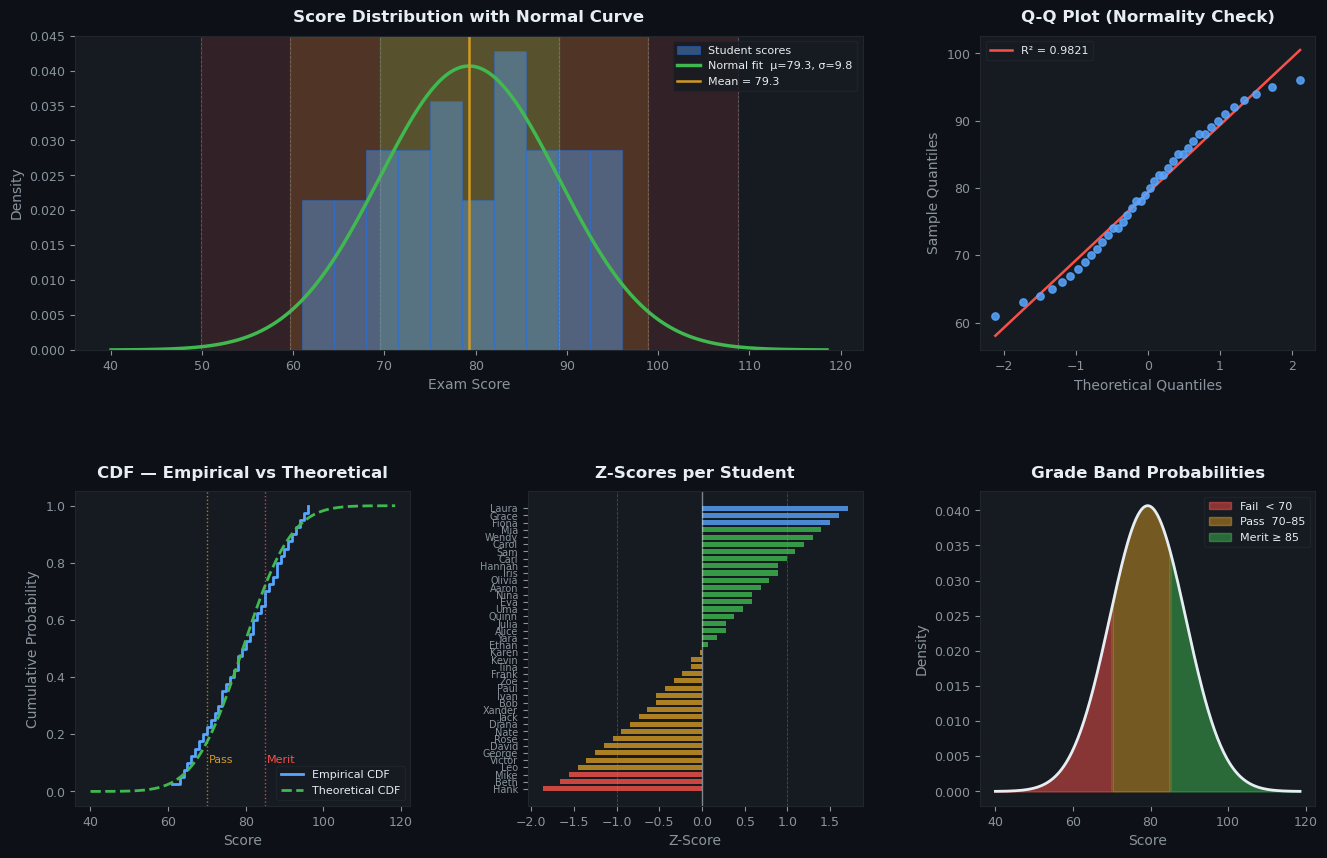

In [5]:
# ── 5. PROBABILITY QUERIES ────────────────────────────────────────────────────

print("\n" + "-" * 55)
print("  PROBABILITY QUERIES")
print("-" * 55)

threshold_pass  = 70
threshold_merit = 85

p_pass   = 1 - stats.norm.cdf(threshold_pass,  mu, sigma)
p_merit  = 1 - stats.norm.cdf(threshold_merit, mu, sigma)
p_mid    = stats.norm.cdf(threshold_merit, mu, sigma) - \
           stats.norm.cdf(threshold_pass,  mu, sigma)

print(f"\n  P(score ≥ {threshold_pass})  = {p_pass*100:.1f}%  → probability of passing")
print(f"  P(score ≥ {threshold_merit})  = {p_merit*100:.1f}%  → probability of merit")
print(f"  P({threshold_pass} ≤ score < {threshold_merit}) = {p_mid*100:.1f}%  → pass but not merit")

# Grade percentile cutoffs
for pct_label, pct_val in [("Top 10%", 90), ("Top 25%", 75), ("Median 50%", 50)]:
    cutoff = stats.norm.ppf(pct_val / 100, mu, sigma)
    print(f"  {pct_label} cutoff score : {cutoff:.1f}")

# ── 6. NORMALITY TEST ─────────────────────────────────────────────────────────

stat_sw, p_sw = stats.shapiro(scores)
stat_ks, p_ks = stats.kstest(scores, 'norm', args=(mu, sigma))

print("\n" + "-" * 55)
print("  NORMALITY TESTS")
print("-" * 55)
print(f"\n  Shapiro-Wilk  : W = {stat_sw:.4f},  p = {p_sw:.4f}  "
      f"→ {'Normal ✓' if p_sw > 0.05 else 'Not normal ✗'}")
print(f"  Kolmogorov-Smirnov : D = {stat_ks:.4f},  p = {p_ks:.4f}  "
      f"→ {'Normal ✓' if p_ks > 0.05 else 'Not normal ✗'}")

# ── 7. PLOTS ──────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

DARK  = '#0d1117'
PANEL = '#161b22'
GRID  = '#21262d'
TEXT  = '#e6edf3'
MUTED = '#8b949e'
BLUE  = '#58a6ff'
TEAL  = '#3fb950'
AMBER = '#d29922'
RED   = '#f85149'

def style_ax(ax):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)
    ax.title.set_color(TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)

# — Plot 1: Histogram + fitted normal PDF ————————————————————
ax1 = fig.add_subplot(gs[0, :2])
style_ax(ax1)

ax1.hist(scores, bins=10, density=True, color=BLUE, alpha=0.4,
         edgecolor='#1f6feb', linewidth=0.8, label='Student scores')

x_pdf = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
y_pdf = stats.norm.pdf(x_pdf, mu, sigma)
ax1.plot(x_pdf, y_pdf, color=TEAL, lw=2.5, label=f'Normal fit  μ={mu:.1f}, σ={sigma:.1f}')

for k, col in [(1, '#3fb95040'), (2, '#d2992230'), (3, '#f8514920')]:
    ax1.axvspan(mu - k*sigma, mu + k*sigma, color=col, zorder=0)
    ax1.axvline(mu - k*sigma, color=MUTED, lw=0.6, ls='--', alpha=0.5)
    ax1.axvline(mu + k*sigma, color=MUTED, lw=0.6, ls='--', alpha=0.5)

ax1.axvline(mu, color=AMBER, lw=1.8, ls='-', label=f'Mean = {mu:.1f}')
ax1.set_title('Score Distribution with Normal Curve', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Exam Score')
ax1.set_ylabel('Density')
ax1.legend(fontsize=8, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)

# — Plot 2: Q-Q Plot ——————————————————————————————————————————
ax2 = fig.add_subplot(gs[0, 2])
style_ax(ax2)

(osm, osr), (slope, intercept, r) = stats.probplot(scores, dist='norm')
ax2.scatter(osm, osr, color=BLUE, s=28, alpha=0.85, zorder=3)
line_x = np.array([osm.min(), osm.max()])
ax2.plot(line_x, slope * line_x + intercept, color=RED, lw=1.8, label=f'R² = {r**2:.4f}')
ax2.set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Theoretical Quantiles')
ax2.set_ylabel('Sample Quantiles')
ax2.legend(fontsize=8, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)

# — Plot 3: CDF ———————————————————————————————————————————————
ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3)

sorted_scores = np.sort(scores)
empirical_cdf = np.arange(1, n + 1) / n
ax3.step(sorted_scores, empirical_cdf, color=BLUE, lw=2, where='post', label='Empirical CDF')
ax3.plot(x_pdf, stats.norm.cdf(x_pdf, mu, sigma), color=TEAL, lw=2, ls='--', label='Theoretical CDF')
ax3.axvline(threshold_pass,  color=AMBER, lw=1, ls=':', alpha=0.8)
ax3.axvline(threshold_merit, color=RED,   lw=1, ls=':', alpha=0.8)
ax3.text(threshold_pass  + 0.5, 0.1, 'Pass', color=AMBER, fontsize=8)
ax3.text(threshold_merit + 0.5, 0.1, 'Merit', color=RED,  fontsize=8)
ax3.set_title('CDF — Empirical vs Theoretical', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('Score')
ax3.set_ylabel('Cumulative Probability')
ax3.legend(fontsize=8, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)

# — Plot 4: Z-Score Bar Chart ———————————————————————————————
ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4)

sorted_z = sorted(zip(names, z_scores), key=lambda x: x[1])
s_names, s_z = zip(*sorted_z)
bar_colors = [RED if z < -1.5 else AMBER if z < 0 else TEAL if z < 1.5 else BLUE for z in s_z]
ax4.barh(range(len(s_z)), s_z, color=bar_colors, alpha=0.8, height=0.7)
ax4.axvline(0, color=TEXT, lw=1, alpha=0.5)
ax4.axvline(-1, color=MUTED, lw=0.6, ls='--', alpha=0.4)
ax4.axvline(+1, color=MUTED, lw=0.6, ls='--', alpha=0.4)
ax4.set_yticks(range(len(s_names)))
ax4.set_yticklabels(s_names, fontsize=7)
ax4.set_title('Z-Scores per Student', fontsize=12, fontweight='bold', pad=10)
ax4.set_xlabel('Z-Score')

# — Plot 5: Probability Shading ——————————————————————————————
ax5 = fig.add_subplot(gs[1, 2])
style_ax(ax5)

ax5.plot(x_pdf, y_pdf, color=TEXT, lw=2)

mask_fail  = x_pdf < threshold_pass
mask_pass  = (x_pdf >= threshold_pass) & (x_pdf < threshold_merit)
mask_merit = x_pdf >= threshold_merit

ax5.fill_between(x_pdf, y_pdf, where=mask_fail,  color=RED,   alpha=0.5, label=f'Fail  < {threshold_pass}')
ax5.fill_between(x_pdf, y_pdf, where=mask_pass,  color=AMBER, alpha=0.5, label=f'Pass  {threshold_pass}–{threshold_merit}')
ax5.fill_between(x_pdf, y_pdf, where=mask_merit, color=TEAL,  alpha=0.5, label=f'Merit ≥ {threshold_merit}')

ax5.set_title('Grade Band Probabilities', fontsize=12, fontweight='bold', pad=10)
ax5.set_xlabel('Score')
ax5.set_ylabel('Density')
ax5.legend(fontsize=8, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)


In [6]:
# — Super title ———————————————————————————————————————————————
fig.suptitle('Normal Distribution — Student Exam Score Analysis',
             fontsize=15, fontweight='bold', color=TEXT, y=1.01)

import os
save_path = r'D:\Python_Git_Rep\Statistics-For-Machine-Learning\Output\normal_dist_students.png'   # ← update this path as needed
os.makedirs(os.path.dirname(save_path), exist_ok=True)

#plt.tight_layout()
fig.savefig(save_path,
            dpi=150,
            bbox_inches='tight',
            facecolor=fig.get_facecolor(),   # use figure's own facecolor — avoids blank image
            edgecolor='none')
#plt.show()   # always AFTER savefig

print("\n  Plots saved → normal_dist_students.png")
print("=" * 55)


  Plots saved → normal_dist_students.png
